# `orbital-game` — 3D RTN workflow walkthrough

Full-3D relative motion: `RTNState` per vehicle (radial / along-track / cross-track) under HCW-RTN dynamics. The defender carries `Mass` so propellant depletes over the rollout.

Steps covered:

1. Build a `ScenarioConfig` for HCW-RTN dynamics
2. Construct an `OrbitalGameEnv` from the config
3. Define a simple defender policy + null policy-state initializer
4. Run two `rollout`s with different seeds
5. Visualize relative motion (R-T, R-N, T-N projections + 3D RTN view)
6. Plot reward curves and propellant-mass curves
7. Save and reload one rollout via HDF5

**Setup.** Run with `uv` (Jupyter is not in the project deps; the easiest way is):

```bash
uv run --with jupyter --with ipykernel jupyter notebook examples/workflow_3d_rtn.ipynb
```

For the 2D (in-plane) variant of this same workflow, see `workflow_2d_rt.ipynb`.

In [10]:
# Auto-reload edited library code without a kernel restart. Run this cell
# again after editing any orbital_game module to pick up the changes.
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, ScenarioConfig, VehicleParamsSpec, rollout, save_run, load_run
from orbital_game.hva import HVAState
from orbital_game.registry import DynamicsKey, StateComponentKey
from orbital_game.sampling.spec import ICSpec
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.mass import ConstantMass
from orbital_game.viz.trajectories import plot_rt, plot_rn, plot_tn, plot_rtn_3d
from orbital_game.viz.summaries import plot_reward_curve

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build a 3D RTN scenario

`ScenarioConfig` is a frozen dataclass that describes everything about a scenario.
We pick a small scenario: 1 defender (with `Mass` so propellant depletes) + 1 intruder, HCW-RTN dynamics (the default), impulsive actuator (also default), each on a 1 km bounded relative orbit with opposite phase.

The IC sampler is `RelativeEllipse`, parameterized by physical ellipse extents in meters: `radial_ellipse_m` is the in-plane semi-major axis, `cross_track_m` is the out-of-plane amplitude, and `phase_rad` controls where on the relative orbit the vehicle sits at t=0. With `delta_a=0` (default), the resulting orbit is bounded — the vehicle stays near the HVA forever, unlike a naive Gaussian on raw RTN state which would drift.

In [ ]:
cfg = ScenarioConfig(
    n_defenders=1,
    n_intruders=1,
    epoch_mjd_utc=60067.0,
    hva=HVAState(
        position_eci=jnp.array([7000e3, 0.0, 0.0]),
        velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
    ),
    defender_components=(StateComponentKey.RTN, StateComponentKey.MASS),
    intruder_components=(StateComponentKey.RTN,),
    defender_params=VehicleParamsSpec(
        dry_mass_kg=100.0, isp_s=220.0, max_thrust_n=5.0,
    ),
    intruder_params=VehicleParamsSpec(
        dry_mass_kg=50.0, isp_s=200.0, max_thrust_n=2.0,
    ),
    ic_sampler=ICSpec(
        # Defender on a 1 km bounded relative orbit, phase=0 -> at radial maximum at t=0
        defender_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0,
            phase_rad=0.0,
            sigma_radial_ellipse_m=10.0,
            mass_sampler=ConstantMass(propellant_mass_kg=10.0),
        ),
        # Intruder on the same ellipse, opposite phase
        intruder_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0,
            phase_rad=jnp.pi,
            sigma_radial_ellipse_m=10.0,
        ),
    ),
    truth_dynamics=DynamicsKey.HCW_RTN,
    planning_dynamics=DynamicsKey.HCW_RTN,
    dt=10.0,
    # Run one full orbit (period ~5828s at r=7000km) plus ~3% margin so the
    # closed/bounded relative trajectory is visually obvious in the plots.
    max_horizon_s=6000.0,
    seed=0,
)

print(f"max_steps (derived): {cfg.max_steps}")
print(f"truth dynamics:     {cfg.truth_dynamics}")
print(f"defender components: {cfg.defender_components}")

max_steps (derived): 600
truth dynamics:     hcw_rtn
defender components: (<StateComponentKey.RTN: 'rtn'>, <StateComponentKey.MASS: 'mass'>)


## 2. Construct the environment

`OrbitalGameEnv(cfg)` resolves all pluggables, assembles per-scenario state classes, builds the `StateLayout`, computes mean motion from the HVA orbit, and stores the IC sampler. It exposes `reset(key)` and `step(key, state, action)` as pure functions.

In [12]:
env = OrbitalGameEnv(cfg)
print(f"mean motion (rad/s): {env.mean_motion:.3e}")
print(f"layout flat dim:     {env.layout.flat_dim}")  # 6 RTN + 1 mass + 6 intruder RTN = 13

mean motion (rad/s): 1.098e-03
layout flat dim:     13


## 3. Define a policy and run two rollouts

The default policy commands zero Δv each step — the defender takes no maneuvers, so the rollout shows **pure HCW dynamics** evolving from the sampled IC. Because the IC sits on a bounded relative orbit (`RelativeEllipse` with `delta_a=0`), you should see a closed 2:1 ellipse in the R-T plane: the defender oscillates between `±radial_ellipse_m` radially and `±2·radial_ellipse_m` along-track, completing one full loop per orbital period. The horizon is set to ~1 orbit so this loop is visible end-to-end.

A commented-out alternative gives the defender small random Gaussian impulses each step — switch to it if you want to see propellant depletion in section 6 (and watch the bounded orbit get nudged).

`init_ps` returns `None` — we don't track belief in this demo. Action shape is `(N_defenders, 3)` for HCW-RTN.

In [13]:
# Default policy: zero-control — no maneuvers, pure HCW dynamics.
def policy(policy_state, obs, key, t):
    del obs, key, t
    return jnp.zeros((cfg.n_defenders, 3)), policy_state

# Alternative: small random Gaussian impulses each step (m/s). Uncomment to
# enable; the defender will perturb its trajectory and visibly deplete
# propellant. Action shape is (N_defenders, 3) for HCW-RTN.
# def policy(policy_state, obs, key, t):
#     del obs, t
#     return jax.random.normal(key, (cfg.n_defenders, 3)) * 0.5, policy_state

def init_ps(config, env_state, key):
    del config, env_state, key
    return None

key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, policy, init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, policy, init_ps, key2, n_steps=cfg.max_steps)

print(f"rollout 1 episode return:  {float(traj1.reward.sum()):.2f}")
print(f"rollout 2 episode return:  {float(traj2.reward.sum()):.2f}")
print(f"rollout 1 first defender RTN pos: {traj1.env_state.defenders.rtn[0, 0, :3]}")
print(f"rollout 2 first defender RTN pos: {traj2.env_state.defenders.rtn[0, 0, :3]}")

rollout 1 episode return:  -923526.54
rollout 2 episode return:  -916806.50
rollout 1 first defender RTN pos: [-1013.22705333     0.             0.        ]
rollout 2 first defender RTN pos: [-1005.85431115     0.             0.        ]


## 4. Visualize relative motion

RTN positions over time, projected onto each pair of axes (R-T, R-N, T-N) and shown together in 3D. Both rollouts overlaid on the same axes so the spread from random IC + policy noise is visible.

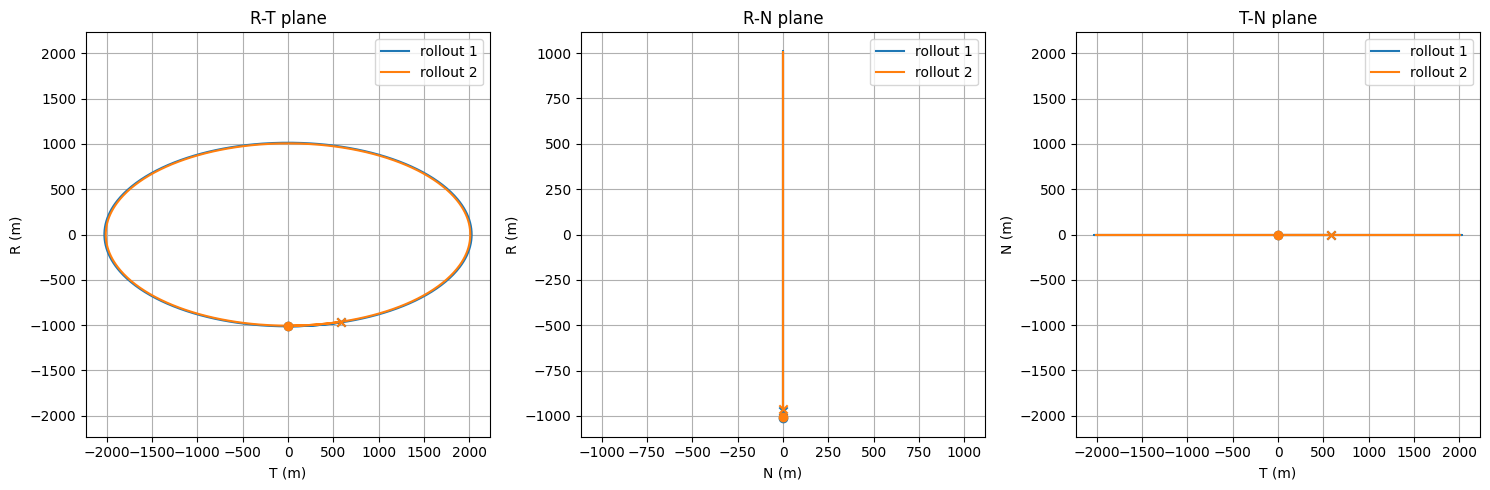

In [14]:
rtn1 = traj1.env_state.defenders.rtn  # (T, N=1, 6)
rtn2 = traj2.env_state.defenders.rtn

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_rt(rtn1, ax=axes[0], label="rollout 1")
plot_rt(rtn2, ax=axes[0], label="rollout 2")
axes[0].legend(); axes[0].set_title("R-T plane")

plot_rn(rtn1, ax=axes[1], label="rollout 1")
plot_rn(rtn2, ax=axes[1], label="rollout 2")
axes[1].legend(); axes[1].set_title("R-N plane")

plot_tn(rtn1, ax=axes[2], label="rollout 1")
plot_tn(rtn2, ax=axes[2], label="rollout 2")
axes[2].legend(); axes[2].set_title("T-N plane")

fig.tight_layout()
plt.show()

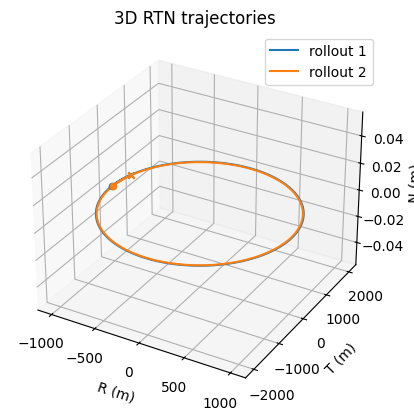

In [15]:
# Full 3D RTN view, both rollouts overlaid (with start/end markers each).
fig3d = plt.figure()
ax3d = fig3d.add_subplot(111, projection="3d")
plot_rtn_3d(rtn1, ax=ax3d, label="rollout 1")
plot_rtn_3d(rtn2, ax=ax3d, label="rollout 2")
ax3d.legend()
ax3d.set_title("3D RTN trajectories")
plt.show()

## 5. Reward curves

Reference reward is `-sum(|defender position|)` per step — the negative 3D distance to the HVA. Bigger (less negative) is closer to the HVA.

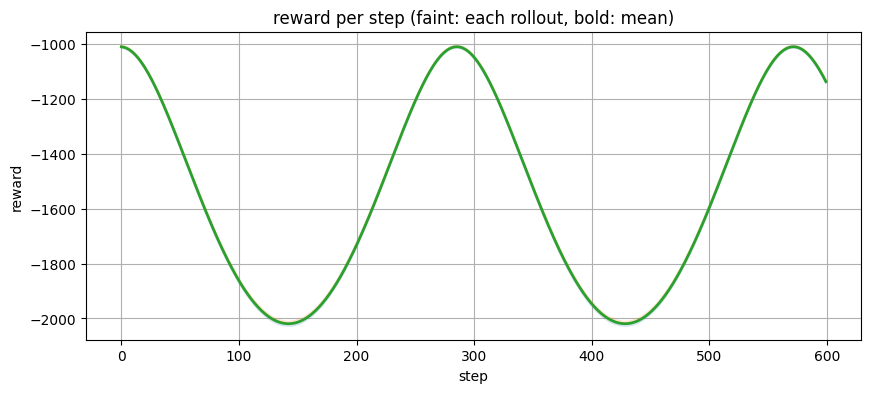

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
rewards = jnp.stack([traj1.reward, traj2.reward], axis=0)  # (B=2, T)
plot_reward_curve(rewards, ax=ax)
ax.set_title("reward per step (faint: each rollout, bold: mean)")
plt.show()

## 6. Propellant mass over time

Because the defender's `Mass` component is in `defender_components`, the impulsive actuator deposits a rocket-equation Δm into `propellant_mass` each step — but only when the actuator command is non-zero. With the default zero-control policy, propellant stays at its initial 10 kg (flat line). Uncomment the random-impulse policy in section 3 to see propellant deplete.

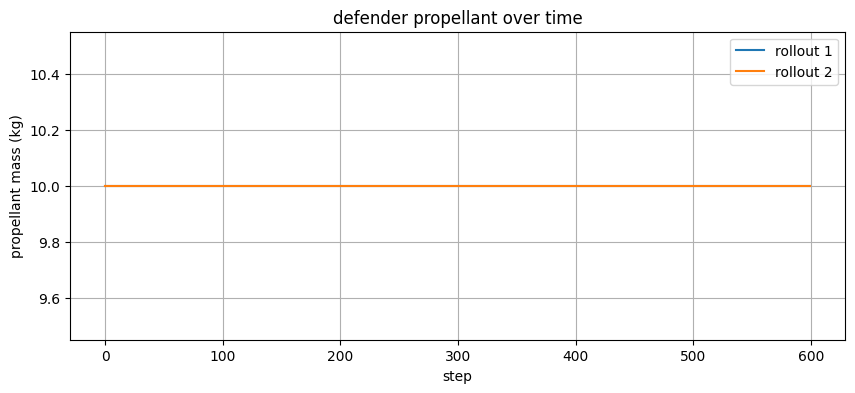

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(traj1.env_state.defenders.propellant_mass[:, 0], label="rollout 1")
ax.plot(traj2.env_state.defenders.propellant_mass[:, 0], label="rollout 2")
ax.set_xlabel("step"); ax.set_ylabel("propellant mass (kg)")
ax.set_title("defender propellant over time"); ax.grid(True); ax.legend()
plt.show()

## 7. Persistence — save and reload via HDF5

`save_run(path, config, traj)` writes the rollout to a single HDF5 file with the full scenario config encoded as a JSON root attribute and each trajectory leaf as a gzip-compressed dataset. `load_run(path)` returns `(config, dict[str, jax.Array])` — the trajectory comes back as a flat name-keyed dict (e.g. `"reward"`, `"action"`, `"env_state.defenders.rtn"`).

In [18]:
import tempfile, pathlib

tmp = pathlib.Path(tempfile.mkdtemp())
out = tmp / "rollout_1.h5"
save_run(out, cfg, traj1)

loaded_cfg, loaded_traj = load_run(out)

print(f"file written:           {out}  ({out.stat().st_size:,} bytes)")
print(f"loaded config matches:  {loaded_cfg.n_defenders == cfg.n_defenders and loaded_cfg.dt == cfg.dt}")
print(f"trajectory keys:        {sorted(loaded_traj.keys())[:6]} ...")
print(f"reward round-trips:     {bool(jnp.allclose(loaded_traj['reward'], traj1.reward))}")

file written:           /var/folders/66/25bqc2bn19bb84ddx70zwv9m0000gn/T/tmpwc0fjzoq/rollout_1.h5  (125,564 bytes)
loaded config matches:  True
trajectory keys:        ['action', 'done', 'env_state.defenders.propellant_mass', 'env_state.defenders.rtn', 'env_state.hva.position_eci', 'env_state.hva.velocity_eci'] ...
reward round-trips:     True


## Next steps

What this bootstrap doesn't yet do, and where the real research starts:

- **Real intruder policies** — replace `ZeroControlIntruder` with adversarial / cooperative behaviours.
- **Partial-observability observation models** — replace `FullObservation` with masking/noisy variants per side. The defender and intruder already have their own `defender_observation_fn` / `intruder_observation_fn` slots.
- **POMDP planners** — consume `env.layout.flatten(env_state.defenders, env_state.intruders)` to get a single flat state vector for belief-space planning.
- **Belief tracking during rollouts** — return a `GaussianBelief` from `init_policy_state_fn` and use it in your policy. The rollout threads it through the scan automatically.
- **Higher-fidelity dynamics** — `astrojax` is wired in as a dep; replace `truth_dynamics` with two-body or full-force propagation while keeping `planning_dynamics = HCW_RTN`.
- **Seed-parallel batches** — `jax.vmap(rollout, in_axes=(None, None, None, 0, None))` over a batch of keys gives you `(B, T, ...)` trajectories with no extra effort.